In [1]:
from __future__ import annotations

import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import copy
import json
import logging
import math
import random
import string
import time
from collections import Counter
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import yaml

In [2]:
@dataclass
class AugConfig:
    """Stochastic augmentation applied on-the-fly, once per epoch per sample."""
    enabled: bool = True
    rotation_deg: float = 5.0
    translate_x: float = 3.0
    translate_y: float = 2.0
    scale_min: float = 0.95
    scale_max: float = 1.05
    noise_std: float = 0.03
    noise_prob: float = 0.5


@dataclass
class DataConfig:
    data_dir: str = "../input/samples"
    img_height: int = 50
    img_width: int = 200
    seq_len: int = 5
    charset: Optional[str] = None
    val_fraction: float = 0.15
    test_fraction: float = 0.15
    aug: AugConfig = field(default_factory=AugConfig)


@dataclass
class ModelConfig:
    conv_filters: List[int] = field(default_factory=lambda: [32, 64, 128])
    dense_units: int = 256
    dropout: float = 0.5
    spatial_dropout: float = 0.25
    rnn_units: int = 128


@dataclass
class TrainConfig:
    epochs: int = 60
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 12
    reduce_lr_patience: int = 5


@dataclass
class EvalConfig:
    """Controls the multi-seed protocol and bootstrap confidence intervals."""
    seeds: List[int] = field(default_factory=lambda: [42, 43, 44])
    bootstrap_samples: int = 2000
    bootstrap_ci: float = 0.95


@dataclass
class Config:
    name: str = "run"
    model_type: str = "cnn_multihead"
    seed: int = 42
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    eval: EvalConfig = field(default_factory=EvalConfig)

    @classmethod
    def from_yaml(cls, path: str) -> "Config":
        with open(path, "r", encoding="utf-8") as fh:
            raw = yaml.safe_load(fh) or {}
        return cls.from_dict(raw)

    @classmethod
    def from_dict(cls, raw: dict) -> "Config":
        raw = dict(raw)
        d = dict(raw.pop("data", {}) or {})
        aug = AugConfig(**(d.pop("aug", {}) or {}))
        data = DataConfig(aug=aug, **d)
        model = ModelConfig(**(raw.pop("model", {}) or {}))
        train = TrainConfig(**(raw.pop("train", {}) or {}))
        ev = EvalConfig(**(raw.pop("eval", {}) or {}))
        return cls(data=data, model=model, train=train, eval=ev, **raw)

    def to_yaml(self, path: str) -> None:
        with open(path, "w", encoding="utf-8") as fh:
            yaml.safe_dump(asdict(self), fh, sort_keys=False)

    @property
    def img_shape(self):
        return (self.data.img_height, self.data.img_width, 1)

In [3]:
def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import tensorflow as tf

        tf.random.set_seed(seed)
        try:
            tf.config.experimental.enable_op_determinism()
        except Exception:
            pass
    except ImportError:
        pass


def get_logger(name: str = "captcha") -> logging.Logger:
    logger = logging.getLogger(name)
    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setFormatter(
            logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S")
        )
        logger.addHandler(handler)
        logger.setLevel(logging.INFO)
    return logger


logger = get_logger()

In [4]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".gif"}


class Vocabulary:
    def __init__(self, chars: List[str]):
        self.chars = list(chars)
        self.char_to_idx: Dict[str, int] = {c: i for i, c in enumerate(self.chars)}
        self.idx_to_char: Dict[int, str] = {i: c for i, c in enumerate(self.chars)}

    @property
    def num_chars(self) -> int:
        return len(self.chars)

    @property
    def blank_index(self) -> int:
        return self.num_chars

    def encode(self, text: str) -> List[int]:
        return [self.char_to_idx[c] for c in text]

    def decode(self, indices) -> str:
        return "".join(self.idx_to_char[int(i)] for i in indices if int(i) in self.idx_to_char)

    def save(self, path: str) -> None:
        with open(path, "w", encoding="utf-8") as fh:
            json.dump({"chars": self.chars}, fh)

    @classmethod
    def load(cls, path: str) -> "Vocabulary":
        with open(path, "r", encoding="utf-8") as fh:
            return cls(json.load(fh)["chars"])


@dataclass
class Sample:
    path: str
    label: str


def _has_images(d: str) -> bool:
    try:
        return any(os.path.splitext(f)[1].lower() in IMAGE_EXTS for f in os.listdir(d))
    except OSError:
        return False


def resolve_data_dir(data_dir: str) -> str:
    if os.path.isdir(data_dir) and _has_images(data_dir):
        return data_dir

    roots = ["../input", "/kaggle/input", "input", "data", "."]
    candidates = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, dirnames, _ in os.walk(root):
            if _has_images(dirpath):
                score = 0 if os.path.basename(dirpath).lower() == "samples" else 1
                candidates.append((score, dirpath))
    if candidates:
        candidates.sort()
        resolved = candidates[0][1]
        logger.info("data_dir '%s' not usable; resolved to '%s'.", data_dir, resolved)
        return resolved

    raise FileNotFoundError(
        f"data_dir '{data_dir}' not found and no image folder located under {roots}. "
        f"Set DATA_DIR to the folder of <label>.png images."
    )


def discover_samples(data_dir: str, seq_len: int, allow_variable_len: bool) -> List[Sample]:
    data_dir = resolve_data_dir(data_dir)

    samples, skipped = [], 0
    for fname in sorted(os.listdir(data_dir)):
        stem, ext = os.path.splitext(fname)
        if ext.lower() not in IMAGE_EXTS:
            continue
        label = stem
        if not label:
            skipped += 1
            continue
        if not allow_variable_len and len(label) != seq_len:
            skipped += 1
            continue
        if len(label) > seq_len:
            skipped += 1
            continue
        samples.append(Sample(os.path.join(data_dir, fname), label))

    if skipped:
        logger.info("Discovered %d samples (%d skipped: bad ext/length).", len(samples), skipped)
    else:
        logger.info("Discovered %d samples.", len(samples))
    if not samples:
        raise RuntimeError(f"No usable images in {data_dir}")
    return samples


def build_vocabulary(samples: List[Sample], charset: Optional[str]) -> Vocabulary:
    if charset:
        return Vocabulary(sorted(set(charset)))
    chars = sorted({c for s in samples for c in s.label})
    logger.info("Inferred charset (%d chars): %s", len(chars), "".join(chars))
    return Vocabulary(chars)


def split_samples(
    samples: List[Sample], val_fraction: float, test_fraction: float, seed: int
) -> Tuple[List[Sample], List[Sample], List[Sample]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(samples))
    rng.shuffle(idx)
    n = len(samples)
    n_test = int(round(n * test_fraction))
    n_val = int(round(n * val_fraction))
    test_idx = idx[:n_test]
    val_idx = idx[n_test : n_test + n_val]
    train_idx = idx[n_test + n_val :]

    pick = lambda ids: [samples[i] for i in ids]
    train, val, test = pick(train_idx), pick(val_idx), pick(test_idx)
    logger.info("Split -> train=%d val=%d test=%d", len(train), len(val), len(test))
    return train, val, test


def save_split(path: str, train, val, test) -> None:
    payload = {
        split: [os.path.basename(s.path) for s in items]
        for split, items in (("train", train), ("val", val), ("test", test))
    }
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(payload, fh, indent=2)


def load_image(path: str, height: int, width: int) -> Optional[np.ndarray]:
    import cv2

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    if img.shape != (height, width):
        img = cv2.resize(img, (width, height), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img[..., np.newaxis]


def augment_image(img: np.ndarray, rng: np.random.Generator, aug: AugConfig) -> np.ndarray:
    """Affine jitter (rotate/scale/translate) plus optional Gaussian noise."""
    import cv2

    h, w = img.shape[:2]
    angle = rng.uniform(-aug.rotation_deg, aug.rotation_deg)
    scale = rng.uniform(aug.scale_min, aug.scale_max)
    tx = rng.uniform(-aug.translate_x, aug.translate_x)
    ty = rng.uniform(-aug.translate_y, aug.translate_y)
    m = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    m[0, 2] += tx
    m[1, 2] += ty
    out = cv2.warpAffine(
        img[..., 0], m, (w, h), borderMode=cv2.BORDER_REPLICATE, flags=cv2.INTER_LINEAR
    )
    if rng.random() < aug.noise_prob:
        out = out + rng.normal(0, aug.noise_std, out.shape).astype(np.float32)
    out = np.clip(out, 0.0, 1.0)
    return out[..., np.newaxis]


def load_clean(samples, cfg: Config) -> Tuple[np.ndarray, List[str]]:
    """Load images once with NO augmentation. Augmentation happens per-epoch in the Sequence."""
    h, w = cfg.data.img_height, cfg.data.img_width
    X, labels = [], []
    for s in samples:
        img = load_image(s.path, h, w)
        if img is None:
            logger.warning("Unreadable image skipped: %s", s.path)
            continue
        X.append(img)
        labels.append(s.label)
    return np.asarray(X, dtype=np.float32), labels


def multihead_targets(labels, cfg: Config, vocab: Vocabulary) -> List[np.ndarray]:
    seq_len, n_cls = cfg.data.seq_len, vocab.num_chars
    y = np.zeros((seq_len, len(labels), n_cls), dtype=np.float32)
    for i, text in enumerate(labels):
        for j, ch in enumerate(text):
            y[j, i, vocab.char_to_idx[ch]] = 1.0
    return [y[j] for j in range(seq_len)]


def ctc_targets(labels, cfg: Config, vocab: Vocabulary):
    max_len = cfg.data.seq_len
    y = np.full((len(labels), max_len), fill_value=-1, dtype=np.int32)
    label_len = np.zeros((len(labels), 1), dtype=np.int32)
    for i, text in enumerate(labels):
        enc = vocab.encode(text)
        y[i, : len(enc)] = enc
        label_len[i, 0] = len(enc)
    return y, label_len

In [5]:
def _levenshtein(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]


def sequence_accuracy(y_true: List[str], y_pred: List[str]) -> float:
    if not y_true:
        return 0.0
    correct = sum(t == p for t, p in zip(y_true, y_pred))
    return correct / len(y_true)


def character_error_rate(y_true: List[str], y_pred: List[str]) -> float:
    total_dist = sum(_levenshtein(t, p) for t, p in zip(y_true, y_pred))
    total_chars = sum(len(t) for t in y_true)
    return total_dist / total_chars if total_chars else 0.0


def per_position_accuracy(y_true: List[str], y_pred: List[str], seq_len: int) -> List[float]:
    correct = np.zeros(seq_len)
    total = np.zeros(seq_len)
    for t, p in zip(y_true, y_pred):
        for j in range(min(len(t), len(p), seq_len)):
            total[j] += 1
            correct[j] += t[j] == p[j]
    return [float(c / n) if n else 0.0 for c, n in zip(correct, total)]


def mean_char_accuracy(y_true: List[str], y_pred: List[str]) -> float:
    correct = total = 0
    for t, p in zip(y_true, y_pred):
        for j in range(min(len(t), len(p))):
            total += 1
            correct += t[j] == p[j]
        total += abs(len(t) - len(p))
    return correct / total if total else 0.0


def char_confusion(y_true: List[str], y_pred: List[str]) -> Counter:
    conf: Counter = Counter()
    for t, p in zip(y_true, y_pred):
        for j in range(min(len(t), len(p))):
            if t[j] != p[j]:
                conf[(t[j], p[j])] += 1
    return conf


def compute_all(y_true: List[str], y_pred: List[str], seq_len: int) -> Dict:
    return {
        "n": len(y_true),
        "sequence_accuracy": sequence_accuracy(y_true, y_pred),
        "mean_char_accuracy": mean_char_accuracy(y_true, y_pred),
        "character_error_rate": character_error_rate(y_true, y_pred),
        "per_position_accuracy": per_position_accuracy(y_true, y_pred, seq_len),
    }


# ---- statistical tooling for research-grade reporting -----------------------
def bootstrap_metric_ci(y_true, y_pred, metric, n_boot=2000, ci=0.95, seed=0):
    """Percentile bootstrap CI for a corpus-level metric over the test set."""
    n = len(y_true)
    point = float(metric(list(y_true), list(y_pred)))
    if n == 0 or n_boot <= 0:
        return point, point, point
    yt = list(y_true)
    yp = list(y_pred)
    rng = np.random.default_rng(seed)
    stats = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        stats[b] = metric([yt[i] for i in idx], [yp[i] for i in idx])
    alpha = (1.0 - ci) / 2.0
    lo, hi = np.quantile(stats, [alpha, 1.0 - alpha])
    return point, float(lo), float(hi)


def mcnemar_sequence(y_true, pred_a, pred_b) -> Dict:
    """Paired McNemar test on exact-sequence correctness (same test set, two models)."""
    from scipy.stats import binomtest, chi2

    a = np.array([t == p for t, p in zip(y_true, pred_a)])
    b = np.array([t == p for t, p in zip(y_true, pred_b)])
    n01 = int(np.sum(~a & b))  # A wrong, B right
    n10 = int(np.sum(a & ~b))  # A right, B wrong
    n = n01 + n10
    if n == 0:
        return {"n01_b_better": 0, "n10_a_better": 0, "stat": 0.0, "p_chi2": 1.0, "p_exact": 1.0}
    stat = (abs(n01 - n10) - 1) ** 2 / n  # with continuity correction
    p_chi2 = float(chi2.sf(stat, 1))
    p_exact = float(binomtest(min(n01, n10), n, 0.5).pvalue)
    return {"n01_b_better": n01, "n10_a_better": n10, "stat": float(stat),
            "p_chi2": p_chi2, "p_exact": p_exact}


def summarize_runs(runs) -> Dict:
    """Mean / sample-std over the per-seed metric values."""
    keys = ["sequence_accuracy", "mean_char_accuracy", "character_error_rate"]
    out = {}
    for k in keys:
        vals = np.array([r["metrics"][k] for r in runs], dtype=float)
        std = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
        out[k] = {"mean": float(vals.mean()), "std": std, "values": [float(v) for v in vals]}
    return out


def representative_run(runs):
    """Run whose sequence accuracy is the median across seeds (used for plots / McNemar)."""
    accs = [r["metrics"]["sequence_accuracy"] for r in runs]
    order = list(np.argsort(accs))
    return runs[order[len(order) // 2]]


def paired_ttest(vals_a, vals_b) -> Dict:
    """Paired t-test across seeds on sequence accuracy."""
    from scipy.stats import ttest_rel

    a = np.asarray(vals_a, dtype=float)
    b = np.asarray(vals_b, dtype=float)
    if len(a) < 2 or len(a) != len(b) or not np.any(a - b):
        return {"t_stat": float("nan"), "p_value": float("nan")}
    res = ttest_rel(a, b)
    return {"t_stat": float(res.statistic), "p_value": float(res.pvalue)}


def pooled_bootstrap_ci(y_true, preds_list, metric, n_boot=2000, ci=0.95, seed=0):
    """Hierarchical bootstrap CI over BOTH training seeds and test items.

    Each iteration resamples one seed's predictions, then resamples test items with
    replacement. The interval therefore reflects training variance + test-set sampling
    and is consistent with the across-seed mean (unlike a CI from a single run).
    """
    n = len(y_true)
    k = len(preds_list)
    point = float(np.mean([metric(list(y_true), list(p)) for p in preds_list])) if k else 0.0
    if n == 0 or k == 0 or n_boot <= 0:
        return point, point, point
    yt = list(y_true)
    rng = np.random.default_rng(seed)
    stats = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        p = preds_list[int(rng.integers(0, k))]
        idx = rng.integers(0, n, n)
        stats[b] = metric([yt[i] for i in idx], [p[i] for i in idx])
    alpha = (1.0 - ci) / 2.0
    lo, hi = np.quantile(stats, [alpha, 1.0 - alpha])
    return point, float(lo), float(hi)


In [6]:
def _reduced(dim: int, n_pools: int) -> int:
    for _ in range(n_pools):
        dim = -(-dim // 2)
    return dim


def build_cnn_multihead(cfg: Config, vocab: Vocabulary):
    """CNN trunk -> column-wise (positional) features -> per-position softmax heads.

    The column reshape keeps the horizontal axis (where characters live) instead of
    flattening the whole feature map into a single huge dense layer, and SpatialDropout2D
    regularizes the trunk. This removes the severe overfitting of a naive Flatten->Dense head.
    """
    from tensorflow import keras
    from tensorflow.keras import layers

    h, w, c = cfg.img_shape
    filters: List[int] = cfg.model.conv_filters
    inp = keras.Input(shape=(h, w, c), name="image")

    x = inp
    for i, f in enumerate(filters):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False, name=f"conv{i+1}")(x)
        x = layers.BatchNormalization(momentum=0.9, name=f"bn{i+1}")(x)
        x = layers.Activation("relu", name=f"relu{i+1}")(x)
        x = layers.MaxPooling2D(padding="same", name=f"pool{i+1}")(x)
        if cfg.model.spatial_dropout > 0:
            x = layers.SpatialDropout2D(cfg.model.spatial_dropout, name=f"sdrop{i+1}")(x)

    hp = _reduced(h, len(filters))
    wp = _reduced(w, len(filters))
    cc = filters[-1]
    x = layers.Permute((2, 1, 3), name="to_columns")(x)       # (W', H', C)
    x = layers.Reshape((wp, hp * cc), name="columns")(x)        # (W', H'*C)
    x = layers.Dense(cfg.model.dense_units, use_bias=False, name="col_dense")(x)
    x = layers.BatchNormalization(momentum=0.9, name="col_bn")(x)
    x = layers.Activation("relu", name="col_relu")(x)
    x = layers.Dropout(cfg.model.dropout, name="col_drop")(x)
    x = layers.Flatten(name="flatten")(x)

    outputs = [
        layers.Dense(vocab.num_chars, activation="softmax", name=f"char_{pos}")(x)
        for pos in range(cfg.data.seq_len)
    ]

    model = keras.Model(inp, outputs, name="cnn_multihead")
    model.compile(
        optimizer=keras.optimizers.Adam(cfg.train.learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def decode_cnn_multihead(model, X, vocab: Vocabulary) -> List[str]:
    import tensorflow as tf

    preds = model.predict(X, verbose=0)
    if not isinstance(preds, list):
        preds = [preds]
    preds = [tf.convert_to_tensor(p).numpy() for p in preds]
    idx = [p.argmax(axis=-1) for p in preds]
    n = idx[0].shape[0]
    results = []
    for i in range(n):
        results.append("".join(vocab.idx_to_char[int(idx[pos][i])] for pos in range(len(idx))))
    return results

In [7]:
def crnn_time_steps(cfg: Config) -> int:
    return _reduced(cfg.data.img_width, len(cfg.model.conv_filters))


def build_crnn_ctc(cfg: Config, vocab: Vocabulary):
    from tensorflow import keras
    from tensorflow.keras import layers

    def _ctc_loss(args):
        y_pred, labels, input_length, label_length = args
        return keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)

    h, w, c = cfg.img_shape
    filters = cfg.model.conv_filters
    n_pools = len(filters)
    t = _reduced(w, n_pools)
    feat_h = _reduced(h, n_pools)
    feature_dim = feat_h * filters[-1]
    n_out = vocab.num_chars + 1

    image = keras.Input(shape=(h, w, c), name="image")
    x = image
    for i, f in enumerate(filters):
        x = layers.Conv2D(f, 3, padding="same", activation="relu", name=f"conv{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn{i+1}")(x)
        x = layers.MaxPooling2D(padding="same", name=f"pool{i+1}")(x)
        if cfg.model.spatial_dropout > 0:
            x = layers.SpatialDropout2D(cfg.model.spatial_dropout, name=f"sdrop{i+1}")(x)

    x = layers.Permute((2, 1, 3), name="to_time_major")(x)
    x = layers.Reshape((t, feature_dim), name="collapse_features")(x)
    x = layers.Dense(64, activation="relu", name="feature_proj")(x)
    x = layers.Dropout(cfg.model.dropout, name="proj_drop")(x)

    x = layers.Bidirectional(
        layers.LSTM(cfg.model.rnn_units, return_sequences=True, dropout=cfg.model.dropout),
        name="bilstm1",
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(cfg.model.rnn_units, return_sequences=True, dropout=cfg.model.dropout),
        name="bilstm2",
    )(x)
    y_pred = layers.Dense(n_out, activation="softmax", name="softmax")(x)

    infer_model = keras.Model(image, y_pred, name="crnn_ctc_infer")

    labels = keras.Input(shape=(cfg.data.seq_len,), dtype="int32", name="labels")
    input_length = keras.Input(shape=(1,), dtype="int32", name="input_length")
    label_length = keras.Input(shape=(1,), dtype="int32", name="label_length")
    loss_out = layers.Lambda(_ctc_loss, output_shape=(1,), name="ctc")(
        [y_pred, labels, input_length, label_length]
    )
    train_model = keras.Model(
        inputs=[image, labels, input_length, label_length],
        outputs=loss_out,
        name="crnn_ctc_train",
    )

    train_model.compile(
        optimizer=keras.optimizers.Adam(cfg.train.learning_rate),
        loss={"ctc": lambda y_true, y_pred: y_pred},
    )
    return train_model, infer_model


def decode_crnn_ctc(infer_model, X, vocab: Vocabulary) -> List[str]:
    import tensorflow as tf
    from tensorflow import keras

    y_pred = infer_model.predict(X, verbose=0)
    input_len = np.full((y_pred.shape[0],), y_pred.shape[1], dtype=np.int32)
    decoded, _ = keras.backend.ctc_decode(y_pred, input_length=input_len, greedy=True)
    decoded = tf.cast(decoded[0], tf.int32).numpy()
    results = []
    for row in decoded:
        results.append(
            "".join(vocab.idx_to_char[int(i)] for i in row if int(i) in vocab.idx_to_char)
        )
    return results


def decode(cfg: Config, model, vocab: Vocabulary, X) -> List[str]:
    if cfg.model_type == "cnn_multihead":
        return decode_cnn_multihead(model, X, vocab)
    elif cfg.model_type == "crnn_ctc":
        return decode_crnn_ctc(model, X, vocab)
    raise ValueError(cfg.model_type)

In [8]:
_SEQ_CLASSES: Dict[str, object] = {}


def _seq_classes():
    """Lazily build Keras Sequence subclasses (keeps this cell importable without TF)."""
    if _SEQ_CLASSES:
        return _SEQ_CLASSES
    from tensorflow.keras.utils import Sequence

    class _AugSequence(Sequence):
        def __init__(self, X, batch_size, aug, seed, shuffle):
            self.X = X
            self.batch_size = int(batch_size)
            self.aug = aug
            self.shuffle = shuffle
            self.base_seed = int(seed)
            self.epoch = 0
            self.indices = np.arange(len(X))
            self._reshuffle()

        def _reshuffle(self):
            self.rng = np.random.default_rng(self.base_seed + self.epoch)
            if self.shuffle:
                self.rng.shuffle(self.indices)

        def __len__(self):
            return int(np.ceil(len(self.X) / self.batch_size))

        def _augment(self, Xb):
            if self.aug is not None and getattr(self.aug, "enabled", False):
                return np.stack([augment_image(x, self.rng, self.aug) for x in Xb])
            return Xb

        def on_epoch_end(self):
            self.epoch += 1
            self._reshuffle()

    class MultiHeadSequence(_AugSequence):
        def __init__(self, X, y_list, batch_size, aug=None, seed=0, shuffle=True):
            super().__init__(X, batch_size, aug, seed, shuffle)
            self.y_list = y_list

        def __getitem__(self, i):
            idx = self.indices[i * self.batch_size : (i + 1) * self.batch_size]
            Xb = self._augment(self.X[idx])
            return Xb, [y[idx] for y in self.y_list]

    class CTCSequence(_AugSequence):
        def __init__(self, X, labels, label_len, input_length, batch_size, aug=None, seed=0, shuffle=True):
            super().__init__(X, batch_size, aug, seed, shuffle)
            self.labels = labels
            self.label_len = label_len
            self.input_length = int(input_length)

        def __getitem__(self, i):
            idx = self.indices[i * self.batch_size : (i + 1) * self.batch_size]
            Xb = self._augment(self.X[idx])
            n = len(idx)
            inputs = {
                "image": Xb,
                "labels": self.labels[idx],
                "input_length": np.full((n, 1), self.input_length, dtype=np.int32),
                "label_length": self.label_len[idx],
            }
            return inputs, np.zeros((n, 1), dtype=np.float32)

    _SEQ_CLASSES["MultiHead"] = MultiHeadSequence
    _SEQ_CLASSES["CTC"] = CTCSequence
    return _SEQ_CLASSES

In [9]:
def build_callbacks(cfg: Config, monitor: str = "val_loss"):
    from tensorflow import keras

    return [
        keras.callbacks.EarlyStopping(
            monitor=monitor, patience=cfg.train.early_stopping_patience,
            restore_best_weights=True, mode="min", verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor, patience=cfg.train.reduce_lr_patience,
            factor=0.5, min_lr=1e-6, mode="min", verbose=1,
        ),
    ]


def train_multihead(cfg, vocab, bundle, seed):
    cls = _seq_classes()["MultiHead"]
    ytr = multihead_targets(bundle["tr_labels"], cfg, vocab)
    yva = multihead_targets(bundle["va_labels"], cfg, vocab)
    model = build_cnn_multihead(cfg, vocab)
    model.summary(print_fn=logger.info)
    train_seq = cls(bundle["Xtr"], ytr, cfg.train.batch_size, aug=cfg.data.aug, seed=seed, shuffle=True)
    val_seq = cls(bundle["Xva"], yva, cfg.train.batch_size, aug=None, seed=seed, shuffle=False)
    hist = model.fit(
        train_seq, validation_data=val_seq, epochs=cfg.train.epochs,
        callbacks=build_callbacks(cfg), verbose=2,
    )
    return model, hist.history


def train_ctc(cfg, vocab, bundle, seed):
    cls = _seq_classes()["CTC"]
    ytr, ltr = ctc_targets(bundle["tr_labels"], cfg, vocab)
    yva, lva = ctc_targets(bundle["va_labels"], cfg, vocab)
    t = crnn_time_steps(cfg)
    train_graph, infer_model = build_crnn_ctc(cfg, vocab)
    infer_model.summary(print_fn=logger.info)
    train_seq = cls(bundle["Xtr"], ytr, ltr, t, cfg.train.batch_size, aug=cfg.data.aug, seed=seed, shuffle=True)
    val_seq = cls(bundle["Xva"], yva, lva, t, cfg.train.batch_size, aug=None, seed=seed, shuffle=False)
    hist = train_graph.fit(
        train_seq, validation_data=val_seq, epochs=cfg.train.epochs,
        callbacks=build_callbacks(cfg), verbose=2,
    )
    return infer_model, hist.history


def fit_model(cfg, vocab, bundle, seed):
    if cfg.model_type == "cnn_multihead":
        return train_multihead(cfg, vocab, bundle, seed)
    elif cfg.model_type == "crnn_ctc":
        return train_ctc(cfg, vocab, bundle, seed)
    raise ValueError(f"Unknown model_type: {cfg.model_type}")

In [10]:
def compute_metrics(cfg, y_true, y_pred, split="test", log=True):
    metrics = compute_all(y_true, y_pred, cfg.data.seq_len)
    metrics["model_type"] = cfg.model_type
    if log:
        logger.info("=== %s | %s split (n=%d) ===", cfg.name, split, metrics["n"])
        logger.info("Sequence accuracy (exact): %.4f", metrics["sequence_accuracy"])
        logger.info("Mean character accuracy  : %.4f", metrics["mean_char_accuracy"])
        logger.info("Character error rate     : %.4f", metrics["character_error_rate"])
        logger.info("Per-position accuracy    : %s",
                    ["%.3f" % a for a in metrics["per_position_accuracy"]])
    return metrics


def evaluate_model(cfg, model, vocab, samples, split="test"):
    X, y_true = load_clean(samples, cfg)
    y_pred = decode(cfg, model, vocab, X)
    metrics = compute_metrics(cfg, y_true, y_pred, split)
    return {**metrics, "X": X, "y_true": y_true, "y_pred": y_pred}


def run_experiment(cfg, vocab, bundle, seeds, log=True):
    """Train + evaluate the model once per seed on the fixed test set."""
    runs = []
    for seed in seeds:
        t0 = time.time()
        set_seed(seed)
        cfg_run = copy.deepcopy(cfg)
        cfg_run.seed = seed
        model, history = fit_model(cfg_run, vocab, bundle, seed)
        y_pred = decode(cfg_run, model, vocab, bundle["test_X"])
        metrics = compute_all(bundle["test_y"], y_pred, cfg_run.data.seq_len)
        runs.append({"seed": seed, "metrics": metrics, "history": history,
                     "y_pred": y_pred, "model": model})
        if log:
            logger.info("[%s seed=%d] seq_acc=%.4f CER=%.4f (%.1fs)",
                        cfg.name, seed, metrics["sequence_accuracy"],
                        metrics["character_error_rate"], time.time() - t0)
    return runs

In [11]:
def test_vocab_roundtrip():
    v = Vocabulary(list("abc012"))
    assert v.num_chars == 6 and v.blank_index == 6
    assert v.decode(v.encode("0a2")) == "0a2"


def test_build_vocabulary_inferred_sorted():
    v = build_vocabulary([Sample("x.png", "b1"), Sample("y.png", "a0")], charset=None)
    assert v.chars == ["0", "1", "a", "b"]


def test_split_is_deterministic_disjoint_and_complete():
    samples = [Sample(f"{i}.png", "aaaaa") for i in range(100)]
    tr1, va1, te1 = split_samples(samples, 0.15, 0.15, seed=42)
    tr2, _, te2 = split_samples(samples, 0.15, 0.15, seed=42)
    names = lambda xs: sorted(s.path for s in xs)
    assert names(tr1) == names(tr2) and names(te1) == names(te2)
    assert len(tr1) == 70 and len(va1) == 15 and len(te1) == 15
    assert len(set(s.path for s in tr1 + va1 + te1)) == 100


def test_sequence_accuracy_is_exact_match():
    assert sequence_accuracy(["abcde", "fghij"], ["abcde", "fgXij"]) == 0.5


def test_mean_char_accuracy():
    assert abs(mean_char_accuracy(["abcde", "fghij"], ["abcde", "fgXij"]) - 0.9) < 1e-9


def test_mean_char_accuracy_length_penalty():
    # length mismatch counts as errors on the missing positions
    assert abs(mean_char_accuracy(["abcde"], ["abc"]) - (3 / 5)) < 1e-9


def test_cer_counts_edits():
    assert character_error_rate(["abc"], ["abc"]) == 0.0
    assert abs(character_error_rate(["abc"], ["abx"]) - (1 / 3)) < 1e-9
    assert abs(character_error_rate(["abc"], ["ab"]) - (1 / 3)) < 1e-9


def test_per_position_accuracy():
    acc = per_position_accuracy(["abcde", "abcde"], ["abcde", "Xbcde"], seq_len=5)
    assert acc[0] == 0.5 and acc[1] == 1.0


def test_reduced_and_time_steps():
    assert _reduced(200, 3) == 25 and _reduced(50, 3) == 7
    assert crnn_time_steps(Config()) == 25


def test_multihead_targets_shapes():
    cfg = Config()
    vocab = Vocabulary(list("0123456789abcdef"))
    y = multihead_targets(["0a1b2"], cfg, vocab)
    assert len(y) == 5 and y[0].shape == (1, 16)
    assert y[1][0].argmax() == vocab.char_to_idx["a"]


def test_ctc_targets_padding():
    cfg = Config()
    vocab = Vocabulary(list("abcde"))
    y, ll = ctc_targets(["abc"], cfg, vocab)
    assert y.shape == (1, 5) and ll[0, 0] == 3
    assert list(y[0, :3]) == vocab.encode("abc") and y[0, 3] == -1 and y[0, 4] == -1


def test_config_roundtrip():
    import tempfile
    cfg_t = Config(name="t", model_type="crnn_ctc")
    cfg_t.train.epochs = 7
    p = os.path.join(tempfile.mkdtemp(), "config.yaml")
    cfg_t.to_yaml(p)
    loaded = Config.from_yaml(p)
    assert loaded.name == "t" and loaded.model_type == "crnn_ctc"
    assert loaded.train.epochs == 7 and loaded.img_shape == (50, 200, 1)


def test_config_nested_aug_eval_roundtrip():
    import tempfile
    cfg = Config(name="t", model_type="crnn_ctc")
    cfg.data.aug.rotation_deg = 9.0
    cfg.data.aug.enabled = False
    cfg.eval.seeds = [1, 2]
    p = os.path.join(tempfile.mkdtemp(), "c.yaml")
    cfg.to_yaml(p)
    loaded = Config.from_yaml(p)
    assert loaded.data.aug.rotation_deg == 9.0 and loaded.data.aug.enabled is False
    assert loaded.eval.seeds == [1, 2]


def test_bootstrap_ci_perfect_is_degenerate():
    yt = ["abcde"] * 50
    m, lo, hi = bootstrap_metric_ci(yt, yt, sequence_accuracy, n_boot=200, seed=0)
    assert m == 1.0 and lo == 1.0 and hi == 1.0


def test_bootstrap_ci_brackets_point_estimate():
    yt = ["aaaaa" for _ in range(100)]
    yp = ["aaaaa" if i < 70 else "bbbbb" for i in range(100)]
    m, lo, hi = bootstrap_metric_ci(yt, yp, sequence_accuracy, n_boot=1000, ci=0.95, seed=1)
    assert abs(m - 0.7) < 1e-9 and lo <= m <= hi and 0.5 < lo < 0.85


def test_mcnemar_detects_difference():
    yt = ["a"] * 100
    pa = ["a"] * 100   # A always right
    pb = ["b"] * 100   # B always wrong
    r = mcnemar_sequence(yt, pa, pb)
    assert r["n10_a_better"] == 100 and r["n01_b_better"] == 0 and r["p_exact"] < 0.01


def test_mcnemar_identical_is_nonsignificant():
    yt = ["a", "b", "c"]
    r = mcnemar_sequence(yt, yt, yt)
    assert r["p_exact"] == 1.0 and r["n01_b_better"] == 0 and r["n10_a_better"] == 0


def test_summarize_runs_mean_std():
    runs = [
        {"metrics": {"sequence_accuracy": 0.8, "mean_char_accuracy": 0.9, "character_error_rate": 0.10}},
        {"metrics": {"sequence_accuracy": 0.9, "mean_char_accuracy": 0.95, "character_error_rate": 0.05}},
    ]
    s = summarize_runs(runs)
    assert abs(s["sequence_accuracy"]["mean"] - 0.85) < 1e-9 and s["sequence_accuracy"]["std"] > 0


def test_representative_run_picks_median():
    runs = [{"metrics": {"sequence_accuracy": a}} for a in (0.6, 0.9, 0.75)]
    assert representative_run(runs)["metrics"]["sequence_accuracy"] == 0.75


def test_paired_ttest_runs():
    res = paired_ttest([0.80, 0.82, 0.79], [0.95, 0.96, 0.97])
    assert res["p_value"] < 0.05 and res["t_stat"] < 0


def test_pooled_bootstrap_ci_brackets_mean():
    yt = ["aaaaa"] * 100
    p1 = ["aaaaa"] * 100                                       # seq_acc 1.0
    p2 = ["aaaaa" if i < 80 else "bbbbb" for i in range(100)]  # seq_acc 0.8
    m, lo, hi = pooled_bootstrap_ci(yt, [p1, p2], sequence_accuracy, n_boot=1000, seed=0)
    assert abs(m - 0.9) < 1e-9 and lo <= m <= hi and lo < 1.0


def _run_all_tests():
    fns = [v for k, v in sorted(globals().items())
           if k.startswith("test_") and callable(v)]
    failed = 0
    for fn in fns:
        try:
            fn()
            print(f"PASS {fn.__name__}")
        except AssertionError as e:
            failed += 1
            print(f"FAIL {fn.__name__}: {e}")
    print(f"\n{len(fns) - failed}/{len(fns)} passed")
    assert failed == 0, "core unit tests failed"


_run_all_tests()

15:23:18 [INFO] Inferred charset (4 chars): 01ab


PASS test_bootstrap_ci_brackets_point_estimate
PASS test_bootstrap_ci_perfect_is_degenerate
PASS test_build_vocabulary_inferred_sorted
PASS test_cer_counts_edits
PASS test_config_nested_aug_eval_roundtrip
PASS test_config_roundtrip
PASS test_ctc_targets_padding


15:23:19 [INFO] Split -> train=70 val=15 test=15
15:23:19 [INFO] Split -> train=70 val=15 test=15


PASS test_mcnemar_detects_difference
PASS test_mcnemar_identical_is_nonsignificant
PASS test_mean_char_accuracy
PASS test_mean_char_accuracy_length_penalty
PASS test_multihead_targets_shapes
PASS test_paired_ttest_runs
PASS test_per_position_accuracy
PASS test_pooled_bootstrap_ci_brackets_mean
PASS test_reduced_and_time_steps
PASS test_representative_run_picks_median
PASS test_sequence_accuracy_is_exact_match
PASS test_split_is_deterministic_disjoint_and_complete
PASS test_summarize_runs_mean_std
PASS test_vocab_roundtrip

21/21 passed


In [12]:
SEED = 42

DATA_DIR = resolve_data_dir("../input/samples")

print("Using dataset:", DATA_DIR)
print("Image files found:", sum(1 for f in os.listdir(DATA_DIR)
                                if os.path.splitext(f)[1].lower() in IMAGE_EXTS))

15:23:19 [INFO] data_dir '../input/samples' not usable; resolved to '../input/datasets/fournierp/captcha-version-2-images/samples'.


Using dataset: ../input/datasets/fournierp/captcha-version-2-images/samples
Image files found: 1070


In [13]:
def make_configs(data_dir: str, seeds=(42, 43, 44)):
    seeds = list(seeds)
    aug = AugConfig(enabled=True, rotation_deg=5.0, translate_x=3.0, translate_y=2.0,
                    scale_min=0.95, scale_max=1.05, noise_std=0.03, noise_prob=0.5)
    cnn = Config(
        name="cnn_multihead", model_type="cnn_multihead", seed=seeds[0],
        data=DataConfig(data_dir=data_dir, img_height=50, img_width=200, seq_len=5,
                        charset=None, val_fraction=0.15, test_fraction=0.15, aug=copy.deepcopy(aug)),
        model=ModelConfig(conv_filters=[32, 64, 128], dense_units=256, dropout=0.5, spatial_dropout=0.25),
        train=TrainConfig(epochs=60, batch_size=32, learning_rate=1e-3,
                          early_stopping_patience=12, reduce_lr_patience=5),
        eval=EvalConfig(seeds=seeds, bootstrap_samples=2000, bootstrap_ci=0.95),
    )
    ctc = Config(
        name="crnn_ctc", model_type="crnn_ctc", seed=seeds[0],
        data=DataConfig(data_dir=data_dir, img_height=50, img_width=200, seq_len=5,
                        charset=None, val_fraction=0.15, test_fraction=0.15, aug=copy.deepcopy(aug)),
        model=ModelConfig(conv_filters=[32, 64, 128], rnn_units=128, dropout=0.25, spatial_dropout=0.0),
        train=TrainConfig(epochs=80, batch_size=32, learning_rate=1e-3,
                          early_stopping_patience=15, reduce_lr_patience=6),
        eval=EvalConfig(seeds=seeds, bootstrap_samples=2000, bootstrap_ci=0.95),
    )
    return [cnn, ctc]


EVAL_SEEDS = [42, 43, 44]
experiment_configs = make_configs(DATA_DIR, seeds=EVAL_SEEDS)
[c.name for c in experiment_configs]

['cnn_multihead', 'crnn_ctc']

In [14]:
# Fixed split + clean (un-augmented) arrays, computed ONCE and shared by every model/seed.
# Keeping the test set fixed across models is what makes the paired McNemar test valid.
base_cfg = experiment_configs[0]
set_seed(SEED)
samples = discover_samples(DATA_DIR, base_cfg.data.seq_len, allow_variable_len=False)
vocab = build_vocabulary(samples, base_cfg.data.charset)
train_s, val_s, test_s = split_samples(
    samples, base_cfg.data.val_fraction, base_cfg.data.test_fraction, SEED
)

Xtr, tr_labels = load_clean(train_s, base_cfg)
Xva, va_labels = load_clean(val_s, base_cfg)
test_X, test_y = load_clean(test_s, base_cfg)

bundle = {
    "Xtr": Xtr, "tr_labels": tr_labels,
    "Xva": Xva, "va_labels": va_labels,
    "test_X": test_X, "test_y": test_y,
}
print(f"train={len(tr_labels)} val={len(va_labels)} test={len(test_y)} | vocab={vocab.num_chars} chars")

2026-06-16 15:23:20.233497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781623400.256109   20474 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781623400.263838   20474 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781623400.281651   20474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781623400.281674   20474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781623400.281677   20474 computation_placer.cc:177] computation placer alr

train=750 val=160 test=160 | vocab=19 chars


In [15]:
# Multi-seed training: each model is trained once per seed; the test set is identical.
study = {"test_X": test_X, "test_y": test_y, "models": {}}
for cfg in experiment_configs:
    print("\n" + "=" * 72)
    print("MODEL:", cfg.name, "| seeds:", cfg.eval.seeds)
    print("=" * 72)
    runs = run_experiment(cfg, vocab, bundle, cfg.eval.seeds)
    study["models"][cfg.name] = {
        "cfg": cfg,
        "runs": runs,
        "summary": summarize_runs(runs),
        "representative": representative_run(runs),
    }

print("\nAll models trained and evaluated across", len(EVAL_SEEDS), "seeds.")


MODEL: cnn_multihead | seeds: [42, 43, 44]


I0000 00:00:1781623405.440205   20474 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781623405.445503   20474 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
15:23:25 [INFO] Model: "cnn_multihead"
15:23:25 [INFO] __________________________________________________________________________________________________
15:23:25 [INFO]  Layer (type)                Output Shape                 Param #   Connected to                  
15:23:25 [INFO] ==================================================================================================
15:23:25 [INFO]  image (InputLayer)          [(None, 50, 200, 1)]         0         []                            
15:23:25 [INFO]                                            

Epoch 1/60


E0000 00:00:1781623408.109954   20474 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_multihead/sdrop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781623408.445873   20534 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781623410.082875   20537 service.cc:152] XLA service 0x7f420434a7a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781623410.082905   20537 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781623410.082908   20537 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781623410.372989   20535 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 - 8s - loss: 19.8559 - char_0_loss: 3.9881 - char_1_loss: 4.0390 - char_2_loss: 3.8892 - char_3_loss: 4.0237 - char_4_loss: 3.9158 - char_0_accuracy: 0.0600 - char_1_accuracy: 0.0480 - char_2_accuracy: 0.0760 - char_3_accuracy: 0.0747 - char_4_accuracy: 0.0707 - val_loss: 15.8796 - val_char_0_loss: 3.2116 - val_char_1_loss: 3.1841 - val_char_2_loss: 2.9933 - val_char_3_loss: 3.2732 - val_char_4_loss: 3.2174 - val_char_0_accuracy: 0.0500 - val_char_1_accuracy: 0.0625 - val_char_2_accuracy: 0.0500 - val_char_3_accuracy: 0.0750 - val_char_4_accuracy: 0.0688 - lr: 0.0010 - 8s/epoch - 336ms/step
Epoch 2/60
24/24 - 1s - loss: 17.7990 - char_0_loss: 3.5600 - char_1_loss: 3.3845 - char_2_loss: 3.5290 - char_3_loss: 3.6368 - char_4_loss: 3.6887 - char_0_accuracy: 0.0787 - char_1_accuracy: 0.1173 - char_2_accuracy: 0.0880 - char_3_accuracy: 0.0933 - char_4_accuracy: 0.0773 - val_loss: 13.5684 - val_char_0_loss: 2.9103 - val_char_1_loss: 2.4907 - val_char_2_loss: 2.6991 - val_char_3_loss: 2

...

Epoch 1/80
24/24 - 12s - loss: 19.6217 - val_loss: 22.8699 - lr: 0.0010 - 12s/epoch - 518ms/step
Epoch 2/80
24/24 - 1s - loss: 16.2653 - val_loss: 17.0620 - lr: 0.0010 - 1s/epoch - 50ms/step
Epoch 3/80
24/24 - 1s - loss: 16.2114 - val_loss: 16.6052 - lr: 0.0010 - 1s/epoch - 48ms/step
Epoch 4/80
24/24 - 1s - loss: 16.1547 - val_loss: 16.4812 - lr: 0.0010 - 1s/epoch - 49ms/step
Epoch 5/80
24/24 - 1s - loss: 16.0277 - val_loss: 16.3862 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 6/80
24/24 - 1s - loss: 15.7145 - val_loss: 16.3642 - lr: 0.0010 - 1s/epoch - 48ms/step
Epoch 7/80
24/24 - 1s - loss: 15.4879 - val_loss: 16.6518 - lr: 0.0010 - 1s/epoch - 48ms/step
Epoch 8/80
24/24 - 1s - loss: 15.1078 - val_loss: 17.6590 - lr: 0.0010 - 1s/epoch - 49ms/step
Epoch 9/80
24/24 - 1s - loss: 14.5194 - val_loss: 18.1782 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 10/80
24/24 - 1s - loss: 13.9160 - val_loss: 19.8678 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 11/80
24/24 - 1s - loss: 12.9717 - val_loss: 20.72

15:29:29 [INFO] [crnn_ctc seed=43] seq_acc=1.0000 CER=0.0000 (87.6s)
15:29:30 [INFO] Model: "crnn_ctc_infer"
15:29:30 [INFO] _________________________________________________________________
15:29:30 [INFO]  Layer (type)                Output Shape              Param #   
15:29:30 [INFO] =================================================================
15:29:30 [INFO]  image (InputLayer)          [(None, 50, 200, 1)]      0         
15:29:30 [INFO]                                                                  
15:29:30 [INFO]  conv1 (Conv2D)              (None, 50, 200, 32)       320       
15:29:30 [INFO]                                                                  
15:29:30 [INFO]  bn1 (BatchNormalization)    (None, 50, 200, 32)       128       
15:29:30 [INFO]                                                                  
15:29:30 [INFO]  pool1 (MaxPooling2D)        (None, 25, 100, 32)       0         
15:29:30 [INFO]                                                        

Epoch 1/80
24/24 - 12s - loss: 19.6300 - val_loss: 28.0410 - lr: 0.0010 - 12s/epoch - 519ms/step
Epoch 2/80
24/24 - 1s - loss: 16.2657 - val_loss: 18.7583 - lr: 0.0010 - 1s/epoch - 52ms/step
Epoch 3/80
24/24 - 1s - loss: 16.2373 - val_loss: 17.1729 - lr: 0.0010 - 1s/epoch - 49ms/step
Epoch 4/80
24/24 - 1s - loss: 16.2005 - val_loss: 16.9499 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 5/80
24/24 - 1s - loss: 16.1368 - val_loss: 17.0504 - lr: 0.0010 - 1s/epoch - 48ms/step
Epoch 6/80
24/24 - 1s - loss: 15.9484 - val_loss: 17.5574 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 7/80
24/24 - 1s - loss: 15.6508 - val_loss: 17.9204 - lr: 0.0010 - 1s/epoch - 48ms/step
Epoch 8/80
24/24 - 1s - loss: 15.3429 - val_loss: 17.7279 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 9/80
24/24 - 1s - loss: 15.0281 - val_loss: 18.0628 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 10/80

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
24/24 - 1s - loss: 14.6575 - val_loss: 18.7896 - lr: 0.0010 -

15:31:16 [INFO] [crnn_ctc seed=44] seq_acc=0.9563 CER=0.0088 (107.0s)



All models trained and evaluated across 3 seeds.


In [16]:
import pandas as pd

# Aggregate table: mean +/- std over seeds, plus a hierarchical (seed + test) bootstrap CI.
rows = []
for name, m in study["models"].items():
    s = m["summary"]
    rep = m["representative"]
    cfg = m["cfg"]
    preds = [r["y_pred"] for r in m["runs"]]
    _, lo, hi = pooled_bootstrap_ci(
        study["test_y"], preds, sequence_accuracy,
        n_boot=cfg.eval.bootstrap_samples, ci=cfg.eval.bootstrap_ci, seed=0,
    )
    rows.append({
        "model": name,
        "seq_acc_mean": s["sequence_accuracy"]["mean"],
        "seq_acc_std": s["sequence_accuracy"]["std"],
        "seq_acc_ci95": f"[{lo:.3f}, {hi:.3f}]",
        "char_acc_mean": s["mean_char_accuracy"]["mean"],
        "CER_mean": s["character_error_rate"]["mean"],
        "n_test": rep["metrics"]["n"],
    })

results_df = pd.DataFrame(rows).set_index("model").sort_values("seq_acc_mean", ascending=False)
display(results_df)

# Head-to-head significance on the SAME fixed test set (representative runs).
names = list(study["models"].keys())
if len(names) == 2:
    a, b = names
    rep_a = study["models"][a]["representative"]["y_pred"]
    rep_b = study["models"][b]["representative"]["y_pred"]
    mc = mcnemar_sequence(study["test_y"], rep_a, rep_b)
    tt = paired_ttest(
        study["models"][a]["summary"]["sequence_accuracy"]["values"],
        study["models"][b]["summary"]["sequence_accuracy"]["values"],
    )
    print(f"\nMcNemar ({a} vs {b}) on exact-sequence correctness:")
    print(f"  discordant: {b} better on {mc['n01_b_better']}, {a} better on {mc['n10_a_better']}")
    print(f"  chi2 p={mc['p_chi2']:.3e} | exact-binomial p={mc['p_exact']:.3e}")
    print(f"Paired t-test across seeds: t={tt['t_stat']:.3f}, p={tt['p_value']:.3e}")

,seq_acc_mean,seq_acc_std,seq_acc_ci95,char_acc_mean,CER_mean,n_test
model,,,,,,
crnn_ctc,0.985417,0.025259,"[0.931, 1.000]",0.996667,0.002917,160
cnn_multihead,0.754167,0.021949,"[0.681, 0.825]",0.927500,0.071250,160



McNemar (cnn_multihead vs crnn_ctc) on exact-sequence correctness:
  discordant: crnn_ctc better on 39, cnn_multihead better on 0
  chi2 p=1.166e-09 | exact-binomial p=3.638e-12
Paired t-test across seeds: t=-8.887, p=1.243e-02


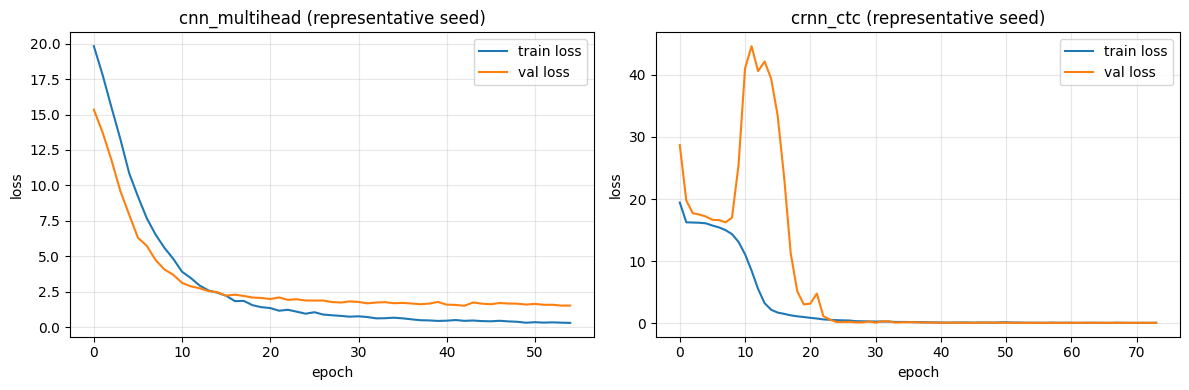

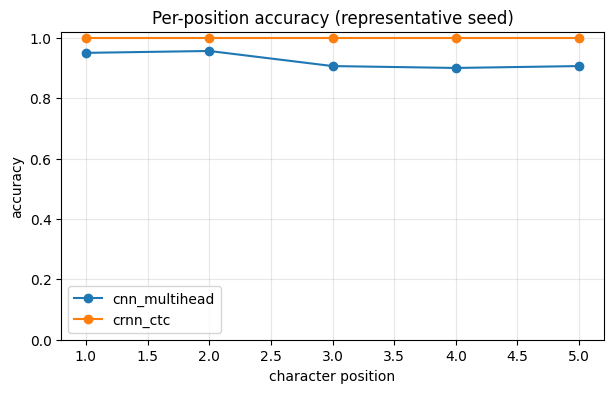


Top 10 confusions (true -> predicted) for cnn_multihead:


,true,predicted,count
0,m,n,12
1,m,w,6
2,n,m,3
3,3,2,2
4,f,d,2
5,2,3,2
6,b,d,2
7,5,e,1
8,3,5,1
9,f,n,1



No character confusions for crnn_ctc (all chars correct).


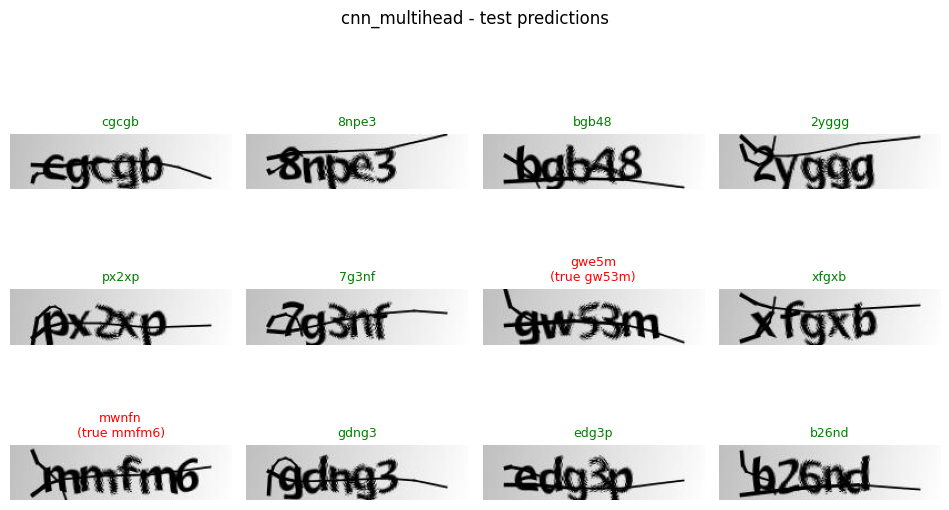

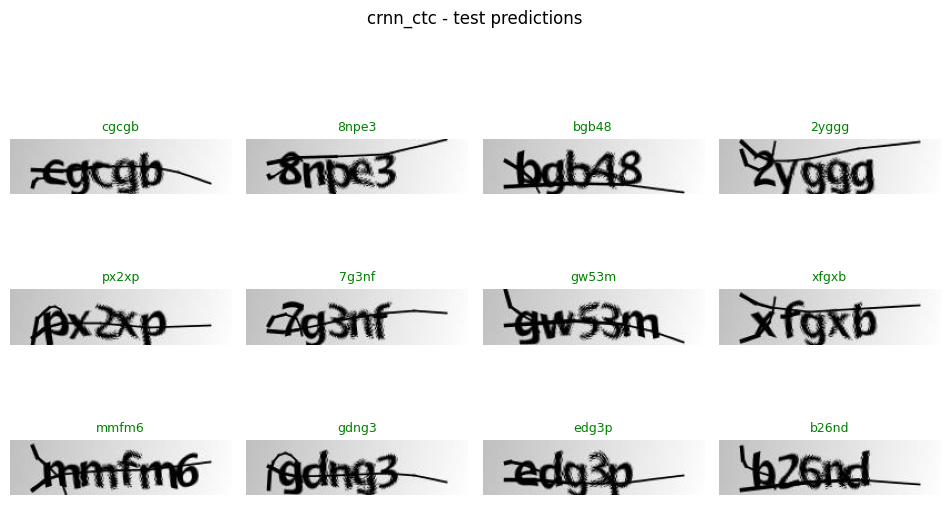

In [17]:
def plot_histories(study):
    import matplotlib.pyplot as plt

    items = list(study["models"].items())
    plt.figure(figsize=(6 * len(items), 4))
    for i, (name, m) in enumerate(items, 1):
        h = m["representative"]["history"]
        ax = plt.subplot(1, len(items), i)
        if "loss" in h:
            ax.plot(h["loss"], label="train loss")
        if "val_loss" in h:
            ax.plot(h["val_loss"], label="val loss")
        ax.set_title(f"{name} (representative seed)")
        ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_per_position(study):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    for name, m in study["models"].items():
        rep = m["representative"]
        acc = per_position_accuracy(study["test_y"], rep["y_pred"], m["cfg"].data.seq_len)
        plt.plot(range(1, len(acc) + 1), acc, marker="o", label=name)
    plt.xlabel("character position"); plt.ylabel("accuracy")
    plt.ylim(0, 1.02); plt.grid(alpha=0.3); plt.legend()
    plt.title("Per-position accuracy (representative seed)"); plt.show()


def show_confusions(study, k=10):
    import pandas as pd

    for name, m in study["models"].items():
        conf = char_confusion(study["test_y"], m["representative"]["y_pred"])
        if conf:
            df = pd.DataFrame([(t, p, c) for (t, p), c in conf.most_common(k)],
                              columns=["true", "predicted", "count"])
            print(f"\nTop {k} confusions (true -> predicted) for {name}:")
            display(df)
        else:
            print(f"\nNo character confusions for {name} (all chars correct).")


def show_samples(study, name, n=12, cols=4):
    import matplotlib.pyplot as plt

    X = study["test_X"]
    y_true = study["test_y"]
    y_pred = study["models"][name]["representative"]["y_pred"]
    n = min(n, len(X))
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 2.4, rows * 1.9))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(X[i].squeeze(), cmap="gray")
        ok = y_true[i] == y_pred[i]
        title = y_pred[i] if ok else f"{y_pred[i]}\n(true {y_true[i]})"
        ax.set_title(title, color="green" if ok else "red", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"{name} - test predictions", y=1.01)
    plt.tight_layout(); plt.show()


plot_histories(study)
plot_per_position(study)
show_confusions(study)
for _name in study["models"]:
    show_samples(study, _name, n=12)

In [18]:
# Ablation: isolate the contribution of on-the-fly augmentation (single seed, for speed).
def run_ablation(configs, vocab, bundle, seed, aug_settings=(True, False)):
    import pandas as pd

    rows = []
    for cfg in configs:
        for aug_on in aug_settings:
            cfg2 = copy.deepcopy(cfg)
            cfg2.data.aug.enabled = aug_on
            set_seed(seed)
            model, _ = fit_model(cfg2, vocab, bundle, seed)
            y_pred = decode(cfg2, model, vocab, bundle["test_X"])
            m = compute_all(bundle["test_y"], y_pred, cfg2.data.seq_len)
            rows.append({"model": cfg.name, "augment": aug_on,
                         "seq_acc": m["sequence_accuracy"],
                         "char_acc": m["mean_char_accuracy"],
                         "CER": m["character_error_rate"]})
            logger.info("[ablation %s aug=%s] seq_acc=%.4f", cfg.name, aug_on, m["sequence_accuracy"])
    return pd.DataFrame(rows)


ablation_df = run_ablation(experiment_configs, vocab, bundle, seed=EVAL_SEEDS[0])
display(ablation_df.pivot(index="model", columns="augment", values="seq_acc")
        .rename(columns={True: "aug_on_seq_acc", False: "aug_off_seq_acc"}))
ablation_df

15:31:17 [INFO] Model: "cnn_multihead"
15:31:17 [INFO] __________________________________________________________________________________________________
15:31:17 [INFO]  Layer (type)                Output Shape                 Param #   Connected to                  
15:31:17 [INFO] ==================================================================================================
15:31:17 [INFO]  image (InputLayer)          [(None, 50, 200, 1)]         0         []                            
15:31:17 [INFO]                                                                                                   
15:31:17 [INFO]  conv1 (Conv2D)              (None, 50, 200, 32)          288       ['image[0][0]']               
15:31:17 [INFO]                                                                                                   
15:31:17 [INFO]  bn1 (BatchNormalization)    (None, 50, 200, 32)          128       ['conv1[0][0]']               
15:31:17 [INFO]                          

Epoch 1/60


E0000 00:00:1781623879.956937   20474 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_multihead/sdrop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


24/24 - 6s - loss: 19.8559 - char_0_loss: 3.9881 - char_1_loss: 4.0390 - char_2_loss: 3.8892 - char_3_loss: 4.0237 - char_4_loss: 3.9158 - char_0_accuracy: 0.0600 - char_1_accuracy: 0.0480 - char_2_accuracy: 0.0760 - char_3_accuracy: 0.0747 - char_4_accuracy: 0.0707 - val_loss: 15.8796 - val_char_0_loss: 3.2116 - val_char_1_loss: 3.1841 - val_char_2_loss: 2.9933 - val_char_3_loss: 3.2732 - val_char_4_loss: 3.2174 - val_char_0_accuracy: 0.0500 - val_char_1_accuracy: 0.0625 - val_char_2_accuracy: 0.0500 - val_char_3_accuracy: 0.0750 - val_char_4_accuracy: 0.0688 - lr: 0.0010 - 6s/epoch - 250ms/step
Epoch 2/60
24/24 - 1s - loss: 17.7990 - char_0_loss: 3.5600 - char_1_loss: 3.3845 - char_2_loss: 3.5290 - char_3_loss: 3.6368 - char_4_loss: 3.6887 - char_0_accuracy: 0.0787 - char_1_accuracy: 0.1173 - char_2_accuracy: 0.0880 - char_3_accuracy: 0.0933 - char_4_accuracy: 0.0773 - val_loss: 13.5684 - val_char_0_loss: 2.9103 - val_char_1_loss: 2.4907 - val_char_2_loss: 2.6991 - val_char_3_loss: 2

15:32:15 [INFO] [ablation cnn_multihead aug=True] seq_acc=0.7312
15:32:15 [INFO] Model: "cnn_multihead"
15:32:15 [INFO] __________________________________________________________________________________________________
15:32:15 [INFO]  Layer (type)                Output Shape                 Param #   Connected to                  
15:32:15 [INFO] ==================================================================================================
15:32:15 [INFO]  image (InputLayer)          [(None, 50, 200, 1)]         0         []                            
15:32:15 [INFO]                                                                                                   
15:32:15 [INFO]  conv1 (Conv2D)              (None, 50, 200, 32)          288       ['image[0][0]']               
15:32:15 [INFO]                                                                                                   
15:32:15 [INFO]  bn1 (BatchNormalization)    (None, 50, 200, 32)          128       ['conv1

...

15:34:35 [INFO] [ablation crnn_ctc aug=True] seq_acc=1.0000
15:34:36 [INFO] Model: "crnn_ctc_infer"
15:34:36 [INFO] _________________________________________________________________
15:34:36 [INFO]  Layer (type)                Output Shape              Param #   
15:34:36 [INFO] =================================================================
15:34:36 [INFO]  image (InputLayer)          [(None, 50, 200, 1)]      0         
15:34:36 [INFO]                                                                  
15:34:36 [INFO]  conv1 (Conv2D)              (None, 50, 200, 32)       320       
15:34:36 [INFO]                                                                  
15:34:36 [INFO]  bn1 (BatchNormalization)    (None, 50, 200, 32)       128       
15:34:36 [INFO]                                                                  
15:34:36 [INFO]  pool1 (MaxPooling2D)        (None, 25, 100, 32)       0         
15:34:36 [INFO]                                                                 

Epoch 1/80
24/24 - 12s - loss: 19.4653 - val_loss: 30.2290 - lr: 0.0010 - 12s/epoch - 494ms/step
Epoch 2/80
24/24 - 1s - loss: 16.2714 - val_loss: 20.2311 - lr: 0.0010 - 1s/epoch - 43ms/step
Epoch 3/80
24/24 - 1s - loss: 16.2300 - val_loss: 17.7970 - lr: 0.0010 - 990ms/epoch - 41ms/step
Epoch 4/80
24/24 - 1s - loss: 16.1867 - val_loss: 17.1887 - lr: 0.0010 - 1s/epoch - 42ms/step
Epoch 5/80
24/24 - 1s - loss: 16.0118 - val_loss: 16.7509 - lr: 0.0010 - 1s/epoch - 43ms/step
Epoch 6/80
24/24 - 1s - loss: 15.5437 - val_loss: 17.1850 - lr: 0.0010 - 964ms/epoch - 40ms/step
Epoch 7/80
24/24 - 1s - loss: 15.1729 - val_loss: 17.1176 - lr: 0.0010 - 986ms/epoch - 41ms/step
Epoch 8/80
24/24 - 1s - loss: 14.6572 - val_loss: 16.5548 - lr: 0.0010 - 981ms/epoch - 41ms/step
Epoch 9/80
24/24 - 1s - loss: 13.3047 - val_loss: 22.7995 - lr: 0.0010 - 987ms/epoch - 41ms/step
Epoch 10/80
24/24 - 1s - loss: 10.2843 - val_loss: 37.3464 - lr: 0.0010 - 978ms/epoch - 41ms/step
Epoch 11/80
24/24 - 1s - loss: 6.3421 

15:35:48 [INFO] [ablation crnn_ctc aug=False] seq_acc=0.9938


augment,aug_off_seq_acc,aug_on_seq_acc
model,,
cnn_multihead,0.58125,0.73125
crnn_ctc,0.99375,1.00000


,model,augment,seq_acc,char_acc,CER
0,cnn_multihead,True,0.73125,0.92500,0.07375
1,cnn_multihead,False,0.58125,0.87875,0.12000
2,crnn_ctc,True,1.00000,1.00000,0.00000
3,crnn_ctc,False,0.99375,0.99875,0.00125


In [19]:
# Persist everything needed to reproduce / write up the study.
def save_artifacts(outdir, study, vocab, train_s, val_s, test_s, results_df, ablation_df=None):
    os.makedirs(outdir, exist_ok=True)
    vocab.save(os.path.join(outdir, "vocab.json"))
    save_split(os.path.join(outdir, "split.json"), train_s, val_s, test_s)
    results_df.to_csv(os.path.join(outdir, "results.csv"))
    if ablation_df is not None:
        ablation_df.to_csv(os.path.join(outdir, "ablation.csv"), index=False)

    summary = {}
    for name, m in study["models"].items():
        cfg = m["cfg"]
        cfg.to_yaml(os.path.join(outdir, f"config_{name}.yaml"))
        summary[name] = {
            "summary": m["summary"],
            "representative_seed": m["representative"]["seed"],
            "representative_metrics": {k: v for k, v in m["representative"]["metrics"].items()},
        }
        rep = m["representative"]["model"]
        try:
            rep.save_weights(os.path.join(outdir, f"weights_{name}.weights.h5"))
        except Exception as exc:
            logger.warning("Could not save weights for %s: %s", name, exc)
    with open(os.path.join(outdir, "summary.json"), "w", encoding="utf-8") as fh:
        json.dump(summary, fh, indent=2)
    logger.info("Artifacts written to %s", os.path.abspath(outdir))


save_artifacts("artifacts", study, vocab, train_s, val_s, test_s, results_df, ablation_df)

15:35:48 [INFO] Artifacts written to /kaggle/working/artifacts


In [20]:
def conclusion(study):
    from IPython.display import Markdown, display

    ranked = sorted(study["models"].items(),
                    key=lambda kv: kv[1]["summary"]["sequence_accuracy"]["mean"], reverse=True)
    lines = ["### Results (mean +/- std over seeds)", "",
             "| model | seq_acc | char_acc | CER |",
             "|---|---|---|---|"]
    for name, m in study["models"].items():
        s = m["summary"]
        lines.append(
            f"| {name} | {s['sequence_accuracy']['mean']:.4f} +/- {s['sequence_accuracy']['std']:.4f} "
            f"| {s['mean_char_accuracy']['mean']:.4f} "
            f"| {s['character_error_rate']['mean']:.4f} |"
        )
    lines.append("")
    best_name, best = ranked[0]
    if len(ranked) > 1:
        second_name, second = ranked[1]
        delta = best["summary"]["sequence_accuracy"]["mean"] - second["summary"]["sequence_accuracy"]["mean"]
        rep_b = study["models"][best_name]["representative"]["y_pred"]
        rep_s = study["models"][second_name]["representative"]["y_pred"]
        mc = mcnemar_sequence(study["test_y"], rep_s, rep_b)
        lines.append(
            f"**Best model: `{best_name}`** - mean exact-sequence accuracy "
            f"{best['summary']['sequence_accuracy']['mean']:.4f}, ahead of `{second_name}` "
            f"by {delta:+.4f}. McNemar exact-binomial p = {mc['p_exact']:.3e} "
            f"(discordant pairs: {mc['n01_b_better']} vs {mc['n10_a_better']})."
        )
    else:
        lines.append(f"**Model `{best_name}`** - mean exact-sequence accuracy "
                     f"{best['summary']['sequence_accuracy']['mean']:.4f}.")
    display(Markdown("\n".join(lines)))


conclusion(study)

### Results (mean +/- std over seeds)

| model | seq_acc | char_acc | CER |
|---|---|---|---|
| cnn_multihead | 0.7542 +/- 0.0219 | 0.9275 | 0.0712 |
| crnn_ctc | 0.9854 +/- 0.0253 | 0.9967 | 0.0029 |

**Best model: `crnn_ctc`** - mean exact-sequence accuracy 0.9854, ahead of `cnn_multihead` by +0.2313. McNemar exact-binomial p = 3.638e-12 (discordant pairs: 39 vs 0).